In [83]:
import json
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from sklearn.metrics import mean_absolute_error
import numpy as np


In [84]:
offshore_gemini_df = pd.read_csv("../datasets/offshore_Gemini.csv", index_col=0, parse_dates=True)
entso_timeseries_df = pd.read_csv("../datasets/entsoe.csv", index_col=0, parse_dates=True)
with open("../metadata_wind_farms.json") as f:
    wind_farms_metadata = json.load(f)["wind_farms"]

In [85]:
# Build a capacity timeline
df_farms = pd.DataFrame(wind_farms_metadata)
df_farms["commissioned"] = pd.to_datetime(df_farms["commissioned"], dayfirst=True)
df_farms["installed_capacity_mw"] = pd.to_numeric(df_farms["installed_capacity_mw"])

luchterduinen = pd.DataFrame([{
    "id": "Luchterduinen",
    "name": "Eneco Luchterduinen",
    "installed_capacity_mw": 129,
    "commissioned": pd.Timestamp("2015-09-21"),
}])

df_farms_plus_luchterduinen = pd.concat([df_farms, luchterduinen], ignore_index=True)
df_farms_plus_luchterduinen = df_farms_plus_luchterduinen.sort_values("commissioned")
df_farms_plus_luchterduinen["cumulative_capacity"] = df_farms_plus_luchterduinen["installed_capacity_mw"].cumsum()

# Sort by commission date and calculate cumulative capacity
df_farms_plus_luchterduinen = df_farms_plus_luchterduinen.sort_values("commissioned")
df_farms_plus_luchterduinen["cumulative_capacity"] = df_farms_plus_luchterduinen["installed_capacity_mw"].cumsum()


start_date = entso_timeseries_df.index.min()

# Filter farms commissioned before the start of the data
df_farms_filtered_luchterduinen = df_farms_plus_luchterduinen[df_farms_plus_luchterduinen["commissioned"] >= start_date].copy()

# Recalculate cumulative capacity starting from whatever was already installed at start_date
baseline_capacity = df_farms_plus_luchterduinen[df_farms_plus_luchterduinen["commissioned"] < start_date]["installed_capacity_mw"].sum()
df_farms_filtered_luchterduinen["cumulative_capacity"] = baseline_capacity + df_farms_filtered_luchterduinen["installed_capacity_mw"].cumsum()

# Extend the step line
end_date = entso_timeseries_df.index.max()

max_capacity = df_farms_filtered_luchterduinen["cumulative_capacity"].max()
commissioned_extended = pd.concat([pd.Series([start_date]), df_farms_filtered_luchterduinen["commissioned"], pd.Series([end_date])])
capacity_extended = pd.concat([pd.Series([baseline_capacity]), df_farms_filtered_luchterduinen["cumulative_capacity"], pd.Series([max_capacity])])

In [86]:
df_farms_plus_luchterduinen

,id,name,installed_capacity_mw,location,commissioned,turbine_type,platform_height,offshore_data_available,turbines,nearest_KNMI_station,cumulative_capacity
6,OWEZ,OWEZ,108.0,NaN,2007-04-18,NaN,NaN,False,NaN,NaN,108.0
5,Windfarm_Princess_Amalia,Windfarm Princess Amalia,120.0,NaN,2008-06-04,NaN,NaN,False,NaN,NaN,228.0
7,Luchterduinen,Eneco Luchterduinen,129.0,NaN,2015-09-21,NaN,NaN,NaN,NaN,NaN,357.0
2,Gemini,Gemini,600.0,"{'lat': 54.03, 'lon': 5.95}",2017-05-08,SWT-4.0-130,120.0,True,150.0,Hoorn,957.0
0,Borssele_12,Borssele 1&2,752.0,"{'lat': 51.75, 'lon': 3.25}",2020-11-27,SG 8.0-167 DD,116.5,True,94.0,Vlissingen,1709.0
1,Borssele_34,Borssele 3&4,731.5,"{'lat': 51.72, 'lon': 3.22}",2021-01-06,V164-9.5,100.0,True,77.0,Vlissingen,2440.5
3,Hollandse_Kust_Zuid,Hollandse Kust Zuid,1529.0,"{'lat': 52.35, 'lon': 4.25}",2023-09-29,SG 11.0-200 DD,125.5,True,139.0,Hoek_van_Holland,3969.5
4,Hollandse_Kust_Noord,Hollandse Kust Noord,759.0,"{'lat': 52.75, 'lon': 4.5}",2023-12-20,SG 11.0-200 DD,125.5,True,69.0,Hoek_van_Holland,4728.5


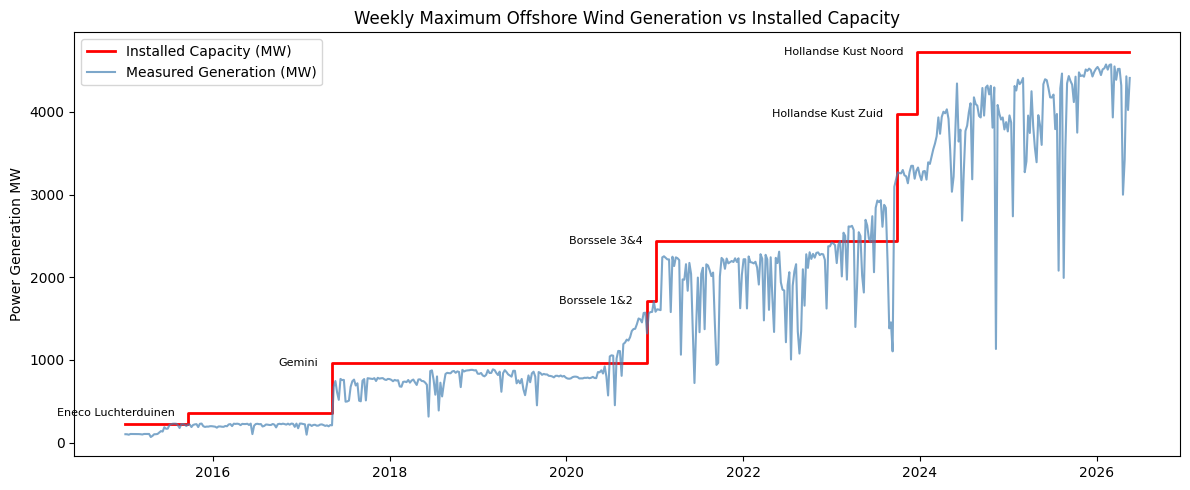

In [87]:
# Plot
fig, ax = plt.subplots(figsize=(12, 5))

ax.step(commissioned_extended, capacity_extended, where="post", color="red", linewidth=2, label="Installed Capacity (MW)")

daily_max = entso_timeseries_df["Generation_MW"].resample("W").max()

ax.plot(daily_max.index, daily_max, color="steelblue", alpha=0.7, label="Measured Generation (MW)")
#ax.plot(entso_timeseries_df.index, entso_timeseries_df["Generation_MW"], color="steelblue", alpha=0.7, label="Generation (MW)")

for _, row in df_farms_plus_luchterduinen.iterrows():
    ax.annotate(row["name"],
                xy=(row["commissioned"], row["cumulative_capacity"]),
                xytext=(-10, 0),
                textcoords="offset points",
                fontsize=8,
                rotation=0,
                ha="right",
                va="center")

ax.set_ylabel("Power Generation MW")
ax.legend()
plt.title("Weekly Maximum Offshore Wind Generation vs Installed Capacity")
plt.tight_layout()
plt.show()

In [88]:
# Build a capacity timeline
df_farms = pd.DataFrame(wind_farms_metadata)
df_farms["commissioned"] = pd.to_datetime(df_farms["commissioned"], dayfirst=True)
df_farms["installed_capacity_mw"] = pd.to_numeric(df_farms["installed_capacity_mw"])

df_farms = df_farms.sort_values("commissioned")
df_farms["cumulative_capacity"] = df_farms["installed_capacity_mw"].cumsum()

# Sort by commission date and calculate cumulative capacity
df_farms = df_farms.sort_values("commissioned")
df_farms["cumulative_capacity"] = df_farms["installed_capacity_mw"].cumsum()


start_date = entso_timeseries_df.index.min()

# Filter farms commissioned before the start of the data
df_farms_filtered = df_farms[df_farms["commissioned"] >= start_date].copy()

# Recalculate cumulative capacity starting from whatever was already installed at start_date
baseline_capacity = df_farms[df_farms["commissioned"] < start_date]["installed_capacity_mw"].sum()
df_farms_filtered["cumulative_capacity"] = baseline_capacity + df_farms_filtered["installed_capacity_mw"].cumsum()

# Extend the step line
end_date = entso_timeseries_df.index.max()

max_capacity = df_farms_filtered["cumulative_capacity"].max()
commissioned_extended = pd.concat([pd.Series([start_date]), df_farms_filtered["commissioned"], pd.Series([end_date])])
capacity_extended = pd.concat([pd.Series([baseline_capacity]), df_farms_filtered["cumulative_capacity"], pd.Series([max_capacity])])

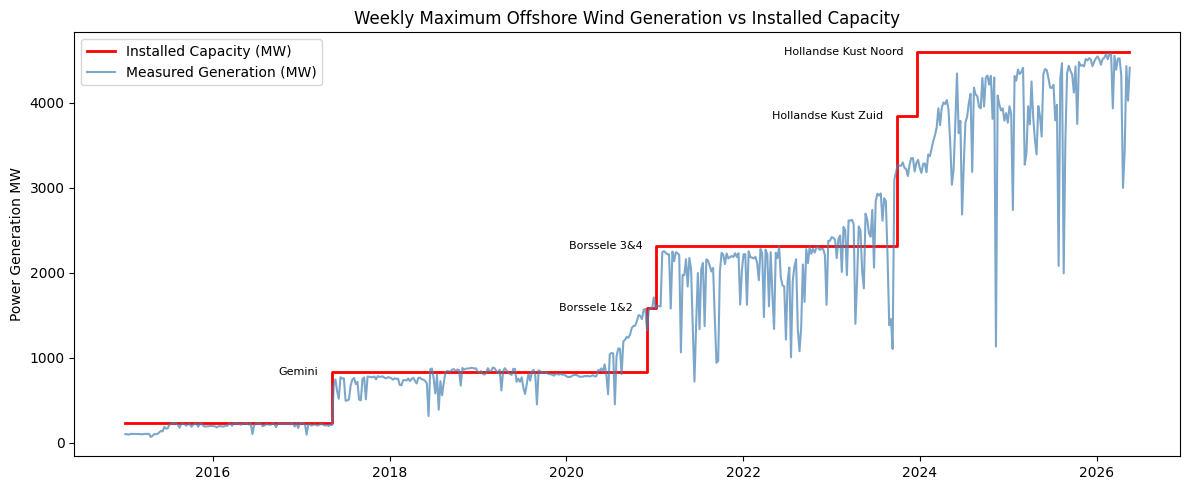

In [89]:
# Plot
fig, ax = plt.subplots(figsize=(12, 5))

ax.step(commissioned_extended, capacity_extended, where="post", color="red", linewidth=2, label="Installed Capacity (MW)")

daily_max = entso_timeseries_df["Generation_MW"].resample("W").max()

ax.plot(daily_max.index, daily_max, color="steelblue", alpha=0.7, label="Measured Generation (MW)")
#ax.plot(entso_timeseries_df.index, entso_timeseries_df["Generation_MW"], color="steelblue", alpha=0.7, label="Generation (MW)")

for _, row in df_farms.iterrows():
    ax.annotate(row["name"],
                xy=(row["commissioned"], row["cumulative_capacity"]),
                xytext=(-10, 0),
                textcoords="offset points",
                fontsize=8,
                rotation=0,
                ha="right",
                va="center")

ax.set_ylabel("Power Generation MW")
ax.legend()
plt.title("Weekly Maximum Offshore Wind Generation vs Installed Capacity")
plt.tight_layout()
plt.show()

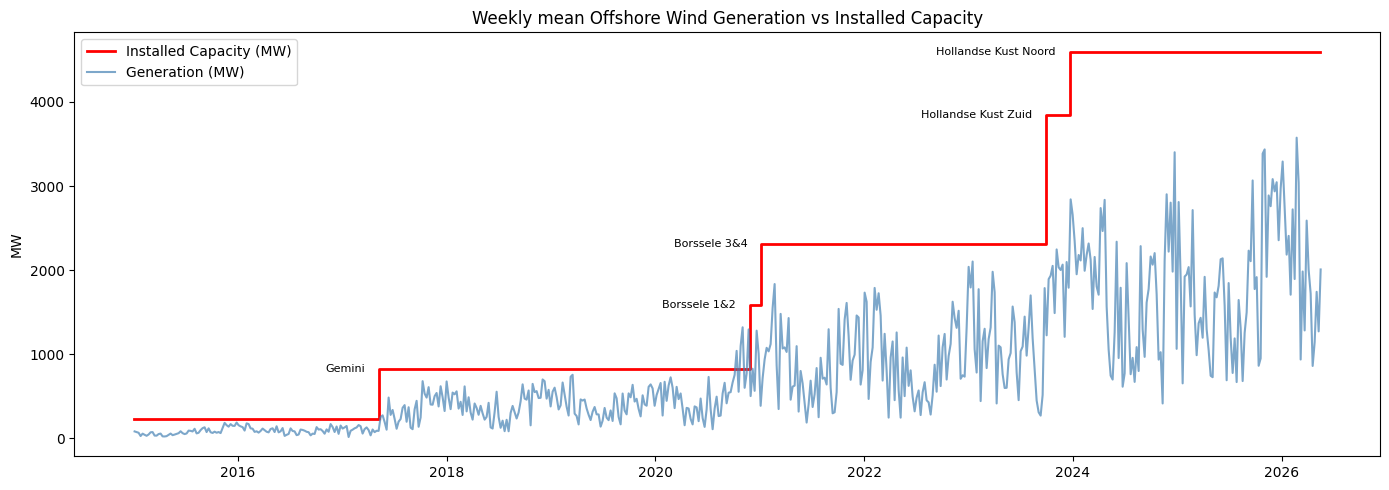

In [90]:
# Plot
fig, ax = plt.subplots(figsize=(14, 5))

ax.step(commissioned_extended, capacity_extended, where="post", color="red", linewidth=2, label="Installed Capacity (MW)")

daily_max = entso_timeseries_df["Generation_MW"].resample("W").mean()

ax.plot(daily_max.index, daily_max, color="steelblue", alpha=0.7, label="Generation (MW)")
#ax.plot(entso_timeseries_df.index, entso_timeseries_df["Generation_MW"], color="steelblue", alpha=0.7, label="Generation (MW)")

for _, row in df_farms.iterrows():
    ax.annotate(row["name"],
                xy=(row["commissioned"], row["cumulative_capacity"]),
                xytext=(-10, 0),
                textcoords="offset points",
                fontsize=8,
                rotation=0,
                ha="right",
                va="center")

ax.set_ylabel("MW")
ax.legend()
plt.title("Weekly mean Offshore Wind Generation vs Installed Capacity")
plt.tight_layout()
plt.show()

In [91]:
# Compare average generation before and after Luchterduinen commissioning
luchterduinen_date = pd.Timestamp("2015-09-21")

before = entso_timeseries_df[
    (entso_timeseries_df.index >= "2015-06-01") &
    (entso_timeseries_df.index < luchterduinen_date)
]["Generation_MW"].mean()

after = entso_timeseries_df[
    (entso_timeseries_df.index >= luchterduinen_date) &
    (entso_timeseries_df.index < "2016-01-01")
]["Generation_MW"].mean()

print(f"Mean before Luchterduinen: {before:.1f} MW")
print(f"Mean after Luchterduinen:  {after:.1f} MW")

Mean before Luchterduinen: 84.1 MW
Mean after Luchterduinen:  120.3 MW


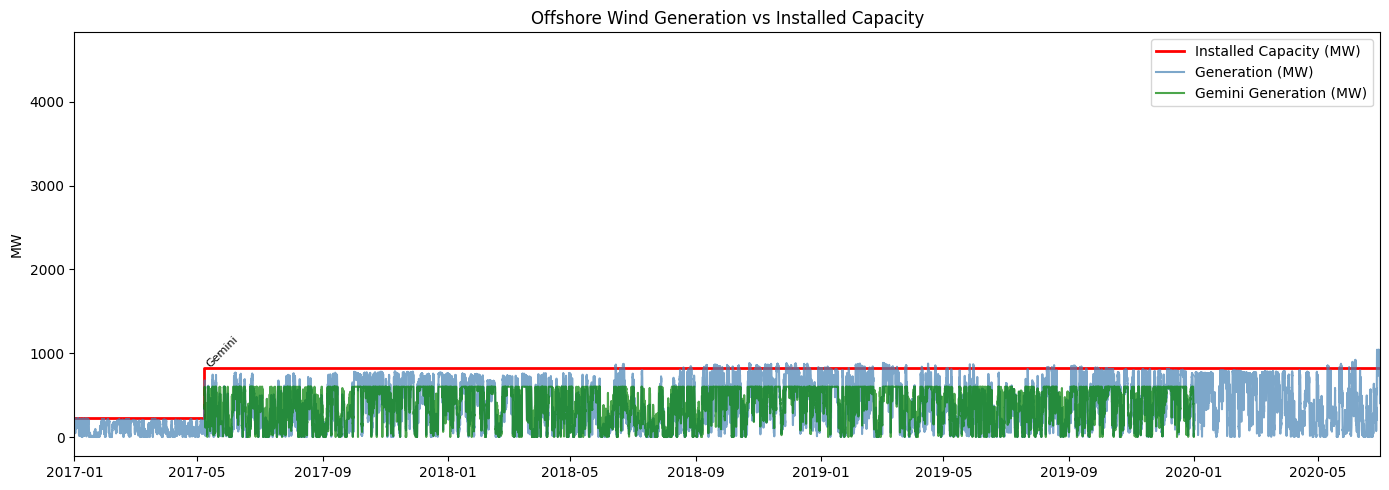

In [92]:
# Plot
fig, ax = plt.subplots(figsize=(14, 5))

ax.step(commissioned_extended, capacity_extended, where="post", color="red", linewidth=2, label="Installed Capacity (MW)")

ax.plot(entso_timeseries_df.index, entso_timeseries_df["Generation_MW"], color="steelblue", alpha=0.7, label="Generation (MW)")

# Gemini individual generation
gemini_start = df_farms[df_farms["name"] == "Gemini"]["commissioned"].values[0]
ax.plot(offshore_gemini_df[offshore_gemini_df.index >= gemini_start]["Power"], color="green", alpha=0.7, label="Gemini Generation (MW)")

for _, row in df_farms.iterrows():
    ax.annotate(row["name"], xy=(row["commissioned"], row["cumulative_capacity"]),
                fontsize=8, rotation=45)

ax.set_xlim(pd.Timestamp("2017-01-01"), pd.Timestamp("2020-07-01"))
ax.set_ylabel("MW")
ax.legend()
plt.title("Offshore Wind Generation vs Installed Capacity")
plt.tight_layout()
plt.show()

In [93]:
# Calculate median generation before Gemini was commissioned
baseline_start = pd.Timestamp("2016-01-01")

pre_gemini_median = entso_timeseries_df[
    (entso_timeseries_df.index >= baseline_start) &
    (entso_timeseries_df.index < gemini_start)
]["Generation_MW"].mean()

pre_gemini_max = entso_timeseries_df[
    (entso_timeseries_df.index >= baseline_start) &
    (entso_timeseries_df.index < gemini_start)
]["Generation_MW"].max()

print("Pre Gemini median of power production:", pre_gemini_median)
print("Pre Gemini max of power production:", pre_gemini_max)



Pre Gemini median of power production: 96.18148168103448
Pre Gemini max of power production: 229.865


In [94]:
# gemini_period_df = entso_timeseries_df[
#     (entso_timeseries_df.index >= gemini_start) &
#     (entso_timeseries_df.index < "2020-01-01")
# ].copy()
#
# gemini_period_df["Generation_excl_baseline_entso"] = (gemini_period_df["Generation_MW"] * (600 / (600 + pre_gemini_max)))
# gemini_period_df["Generation_offshore"] = offshore_gemini_df.loc[
#     (offshore_gemini_df.index >= gemini_start) &
#     (offshore_gemini_df.index < "2020-01-01"),
#     "Power"
# ]

In [95]:
gemini_period_df = entso_timeseries_df[
    (entso_timeseries_df.index >= gemini_start) &
    (entso_timeseries_df.index < "2020-01-01")
].copy().rename(columns={"Generation_MW": "Generation_ENTSOE"})

gemini_period_df["Generation_offshore"] = offshore_gemini_df.loc[
    (offshore_gemini_df.index >= gemini_start) &
    (offshore_gemini_df.index < "2020-01-01"),
    "Power"
]

In [96]:
gemini_period_df

,Generation_ENTSOE,Generation_offshore
Datetime,,
2017-05-08 00:00:00,346.3625,380.585540
2017-05-08 01:00:00,297.7425,358.059540
2017-05-08 02:00:00,279.7725,333.529500
2017-05-08 03:00:00,217.5150,366.451540
2017-05-08 04:00:00,199.9375,449.258700
...,...,...
2019-12-31 19:00:00,7.8650,11.280157
2019-12-31 20:00:00,16.9300,0.000000
2019-12-31 21:00:00,30.0025,0.000000


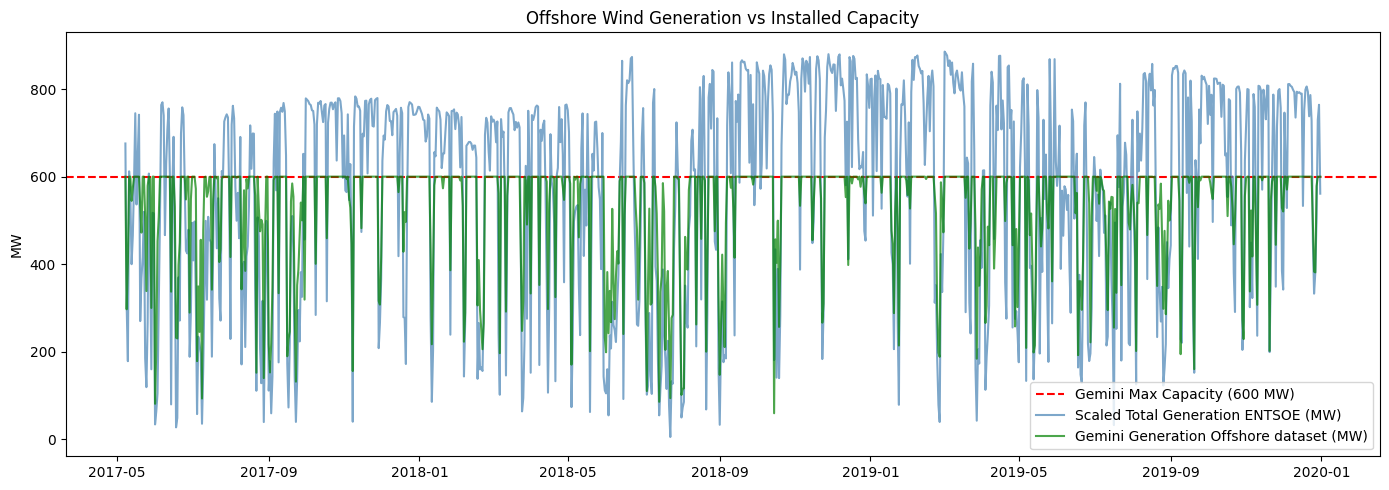

In [141]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.axhline(y=600, color="red", linewidth=1.5, linestyle="--", label="Gemini Max Capacity (600 MW)")

ax.plot(gemini_period_df["Generation_ENTSOE"].resample("D").max(),
        color="steelblue", alpha=0.7, label="Scaled Total Generation ENTSOE (MW)")

ax.plot(gemini_period_df["Generation_offshore"].resample("D").max(),
        color="green", alpha=0.7, label="Gemini Generation Offshore dataset (MW)")

ax.set_ylabel("MW")
ax.legend()
plt.title("Offshore Wind Generation vs Installed Capacity")
plt.tight_layout()
plt.show()

In [98]:
# # Plot
# fig, ax = plt.subplots(figsize=(14, 5))
#
# ax.axhline(y=600, color="red", linewidth=1.5, linestyle="--", label="Gemini Max Capacity (600 MW)")
#
# ax.plot(gemini_period_df.index, gemini_period_df["Generation_excl_baseline_entso"], color="steelblue", alpha=0.7, label="Scaled Total Generation ENTSOE (MW)")
#
# # Gemini individual generation
# ax.plot(gemini_period_df.index, gemini_period_df["Generation_offshore"], color="green", alpha=0.7, label="Gemini Generation Offshore dataset (MW)")
#
# ax.set_ylabel("MW")
# ax.legend()
# plt.title("Offshore Wind Generation vs Installed Capacity")
# plt.tight_layout()
# plt.show()

In [99]:
# from sklearn.metrics import mean_absolute_error
# import numpy as np
#
# mae = mean_absolute_error(gemini_period_df["Generation_excl_baseline_entso"], gemini_period_df["Generation_offshore"])
# rmse = np.sqrt(((gemini_period_df["Generation_offshore"] - gemini_period_df["Generation_excl_baseline_entso"])**2).mean())
# correlation = gemini_period_df["Generation_offshore"].corr(gemini_period_df["Generation_excl_baseline_entso"])
# print(f"mae: {mae}, rmse: {rmse}, correlation: {correlation}")

In [100]:
# gemini_period_df["error"] = (
#     gemini_period_df["Generation_offshore"] -
#     gemini_period_df["Generation_excl_baseline_entso"]
# )
#
# # Check if error is systematic
# print(gemini_period_df["error"].describe())
#
# # Plot error over time to see if it is worse in certain periods
# gemini_period_df["error"].resample("ME").mean().plot()

In [101]:
# gemini_period_df["error"].resample("ME").mean().plot()
# gemini_period_df["Generation_offshore"].resample("ME").mean().plot()

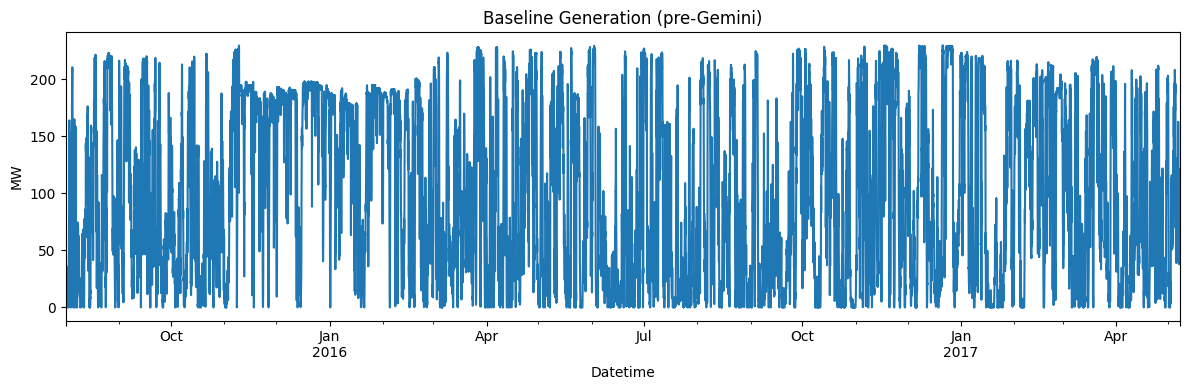

In [102]:
baseline_start = pd.Timestamp("2015-08-01")

entso_timeseries_df[
    (entso_timeseries_df.index >= baseline_start) &
    (entso_timeseries_df.index < gemini_start)
]["Generation_MW"].plot(figsize=(12, 4))

plt.title("Baseline Generation (pre-Gemini)")
plt.ylabel("MW")
plt.tight_layout()
plt.show()

In [103]:
monthly_mean = entso_timeseries_df[
    (entso_timeseries_df.index >= baseline_start) &
    (entso_timeseries_df.index < gemini_start)
].groupby(entso_timeseries_df[
    (entso_timeseries_df.index >= baseline_start) &
    (entso_timeseries_df.index < gemini_start)
].index.month)["Generation_MW"].mean()

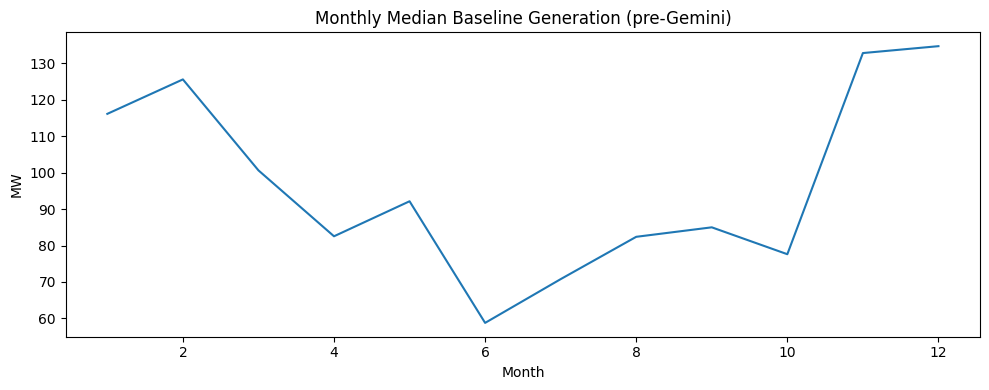

In [104]:
monthly_mean.plot(figsize=(10, 4))
plt.xlabel("Month")
plt.ylabel("MW")
plt.title("Monthly Median Baseline Generation (pre-Gemini)")
plt.tight_layout()
plt.show()

In [105]:
gemini_period_df["Generation_offshore_plus_baseline"] = gemini_period_df.apply(
    lambda row: row["Generation_offshore"] + monthly_mean[row.name.month], axis=1
)

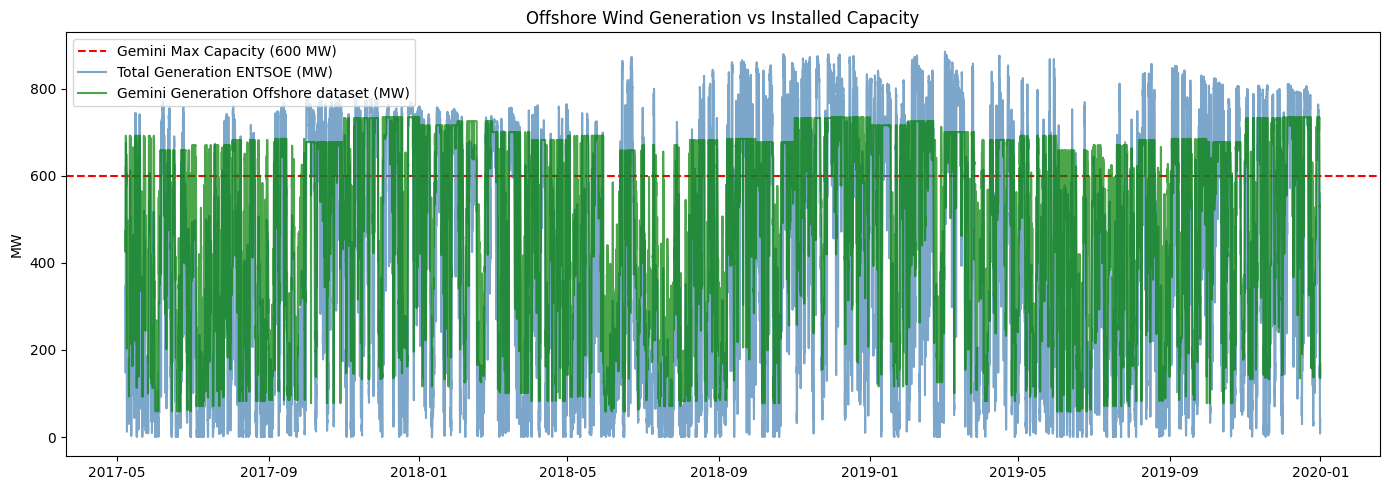

In [106]:
# Plot
fig, ax = plt.subplots(figsize=(14, 5))

ax.axhline(y=600, color="red", linewidth=1.5, linestyle="--", label="Gemini Max Capacity (600 MW)")

ax.plot(gemini_period_df.index, gemini_period_df["Generation_ENTSOE"], color="steelblue", alpha=0.7, label="Total Generation ENTSOE (MW)")

# Gemini individual generation
ax.plot(gemini_period_df.index, gemini_period_df["Generation_offshore_plus_baseline"], color="green", alpha=0.7, label="Gemini Generation Offshore dataset (MW)")

ax.set_ylabel("MW")
ax.legend()
plt.title("Offshore Wind Generation vs Installed Capacity")
plt.tight_layout()
plt.show()

In [107]:
mae = mean_absolute_error(gemini_period_df["Generation_ENTSOE"], gemini_period_df["Generation_offshore_plus_baseline"])
rmse = np.sqrt(((gemini_period_df["Generation_ENTSOE"] - gemini_period_df["Generation_offshore_plus_baseline"])**2).mean())
correlation = gemini_period_df["Generation_ENTSOE"].corr(gemini_period_df["Generation_offshore_plus_baseline"])
print(f"mae: {mae}, rmse: {rmse}, correlation: {correlation}")

mae: 157.89633435079458, rmse: 190.40027395600077, correlation: 0.8612082016884294


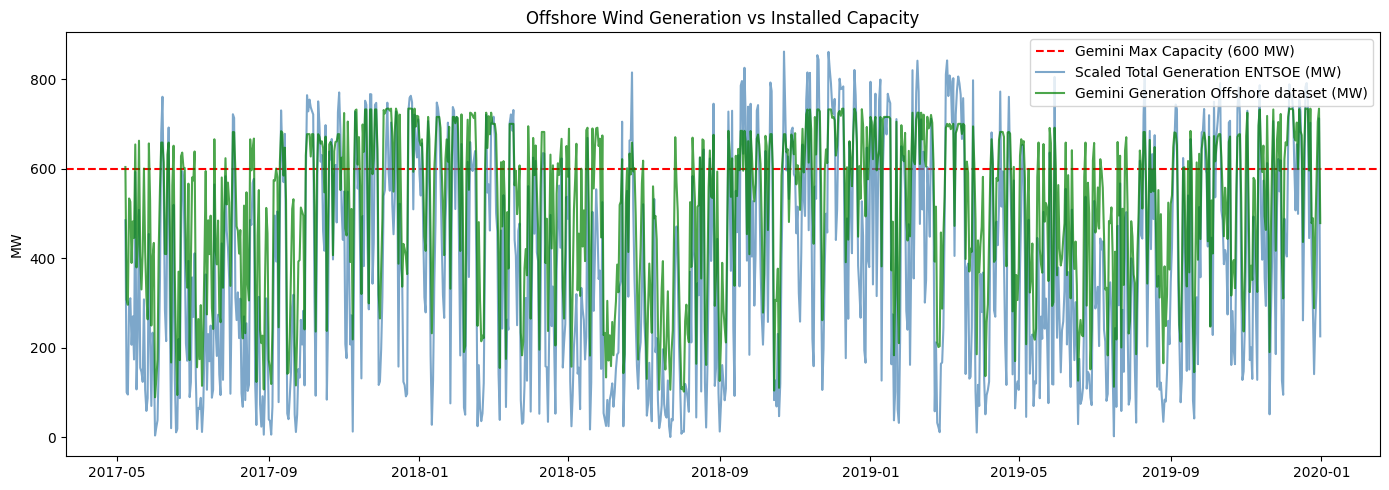

In [108]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.axhline(y=600, color="red", linewidth=1.5, linestyle="--", label="Gemini Max Capacity (600 MW)")

ax.plot(gemini_period_df["Generation_ENTSOE"].resample("D").mean(),
        color="steelblue", alpha=0.7, label="Scaled Total Generation ENTSOE (MW)")

ax.plot(gemini_period_df["Generation_offshore_plus_baseline"].resample("D").mean(),
        color="green", alpha=0.7, label="Gemini Generation Offshore dataset (MW)")

ax.set_ylabel("MW")
ax.legend()
plt.title("Offshore Wind Generation vs Installed Capacity")
plt.tight_layout()
plt.show()

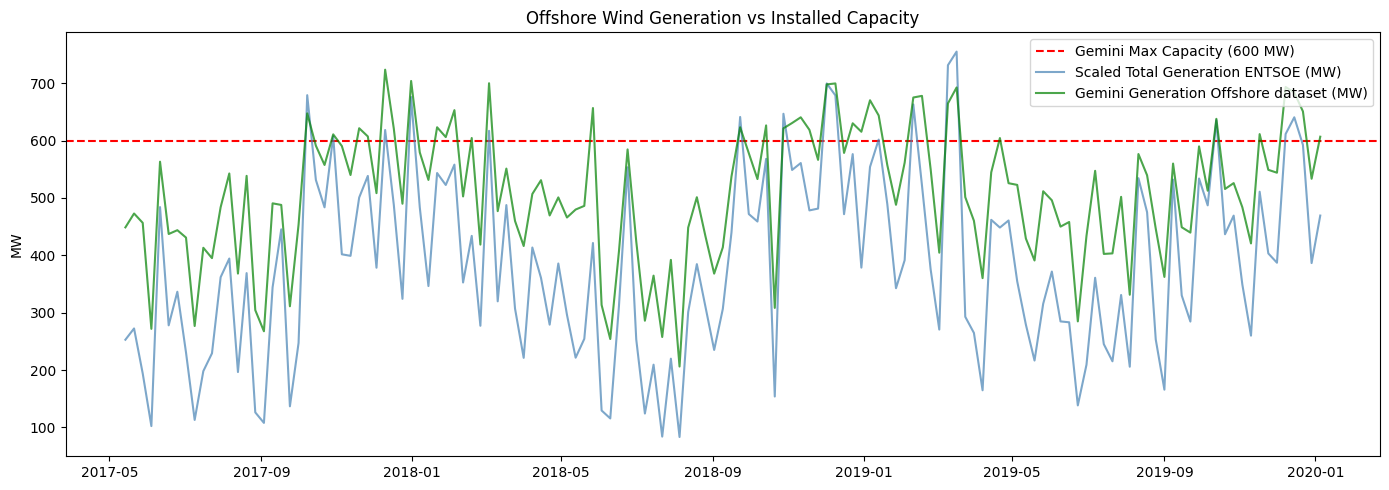

In [109]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.axhline(y=600, color="red", linewidth=1.5, linestyle="--", label="Gemini Max Capacity (600 MW)")

ax.plot(gemini_period_df["Generation_ENTSOE"].resample("W").mean(),
        color="steelblue", alpha=0.7, label="Scaled Total Generation ENTSOE (MW)")

ax.plot(gemini_period_df["Generation_offshore_plus_baseline"].resample("W").mean(),
        color="green", alpha=0.7, label="Gemini Generation Offshore dataset (MW)")

ax.set_ylabel("MW")
ax.legend()
plt.title("Offshore Wind Generation vs Installed Capacity")
plt.tight_layout()
plt.show()

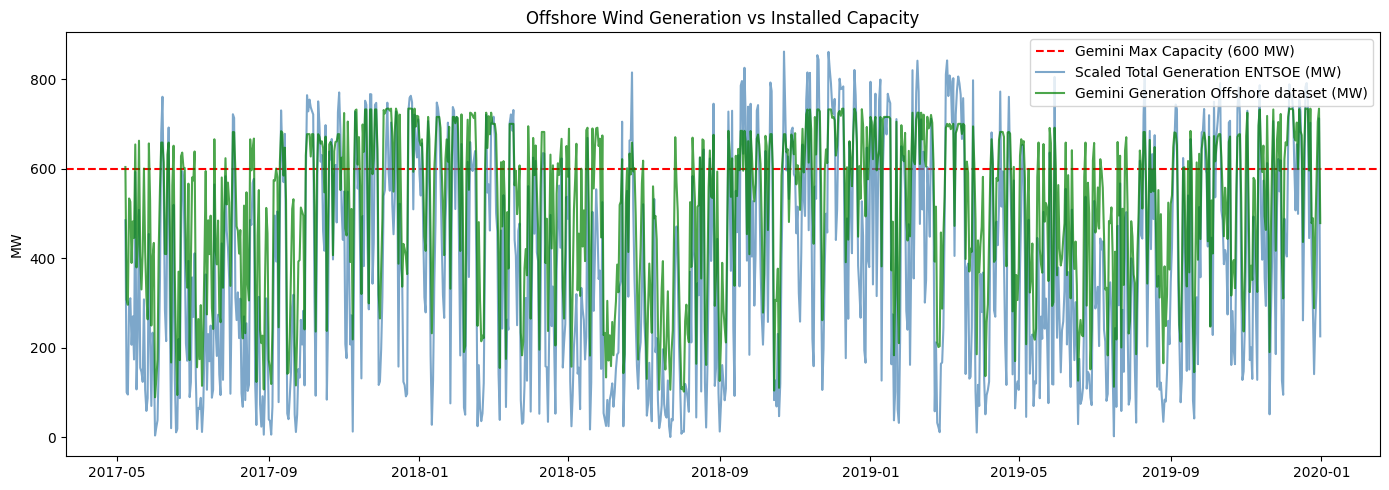

In [110]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.axhline(y=600, color="red", linewidth=1.5, linestyle="--", label="Gemini Max Capacity (600 MW)")

ax.plot(gemini_period_df["Generation_ENTSOE"].resample("D").mean(),
        color="steelblue", alpha=0.7, label="Scaled Total Generation ENTSOE (MW)")

ax.plot(gemini_period_df["Generation_offshore_plus_baseline"].resample("D").mean(),
        color="green", alpha=0.7, label="Gemini Generation Offshore dataset (MW)")

ax.set_ylabel("MW")
ax.legend()
plt.title("Offshore Wind Generation vs Installed Capacity")
plt.tight_layout()
plt.show()

In [111]:
# # Weekly resampled data
# x = gemini_period_df["Generation_excl_baseline_entso"].resample("D").mean().dropna()
# y = gemini_period_df["Generation_offshore"].resample("D").mean().dropna()
#
# # Align on index
# x, y = x.align(y, join="inner")
#
# # Linear fit
# slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
#
# print(f"Slope:     {slope:.4f}")
# print(f"Intercept: {intercept:.4f}")
# print(f"R²:        {r_value**2:.4f}")
# print(f"R:         {r_value:.4f}")
# print(f"P-value:   {p_value:.6f}")
# print(f"Std error: {std_err:.4f}")
#
# # Plot
# fig, ax = plt.subplots(figsize=(8, 8))
#
# ax.scatter(x, y, alpha=0.5, s=15, color="steelblue", label="Weekly mean")
#
# # Perfect correlation line
# max_val = max(x.max(), y.max())
# ax.plot([0, max_val], [0, max_val], color="red", linestyle="--", linewidth=1.5, label="Perfect correlation")
#
# # Linear fit line
# x_line = np.linspace(x.min(), x.max(), 100)
# y_line = slope * x_line + intercept
# ax.plot(x_line, y_line, color="orange", linewidth=2, label=f"Linear fit (R²={r_value**2:.3f})")
#
# ax.axvline(x=600, color="grey", linestyle="--", linewidth=1, alpha=0.5, label="Gemini Max Capacity (600 MW)")
# ax.axhline(y=600, color="grey", linestyle="--", linewidth=1, alpha=0.5)
#
# ax.set_xlabel("Scaled Total Generation ENTSOE (MW)")
# ax.set_ylabel("Gemini Generation Offshore dataset (MW)")
# ax.legend()
# plt.title("ENTSOE vs Offshore Dataset -- Weekly Mean")
# plt.tight_layout()
# plt.show()

In [112]:
# # Weekly resampled data
# x = gemini_period_df["Generation_excl_baseline_entso"].resample("D").mean().dropna()
# y = gemini_period_df["Generation_offshore"].resample("D").mean().dropna()
# # y = x + intercept  ->  intercept = mean(y - x)
# intercept_fixed = (y - x).mean()
#
# print(f"Fixed slope fit:")
# print(f"Slope:     1.0000 (fixed)")
# print(f"Intercept: {intercept_fixed:.4f}")
#
# # Residuals for R²
# y_pred_fixed = x + intercept_fixed
# ss_res = ((y - y_pred_fixed) ** 2).sum()
# ss_tot = ((y - y.mean()) ** 2).sum()
# r2_fixed = 1 - ss_res / ss_tot
# print(f"R²:        {r2_fixed:.4f}")
#
# # Plot
# fig, ax = plt.subplots(figsize=(8, 8))
#
# ax.scatter(x, y, alpha=0.5, s=15, color="steelblue", label="Daily mean")
#
# max_val = max(x.max(), y.max())
# ax.plot([0, max_val], [0, max_val], color="red", linestyle="--", linewidth=1.5, label="Perfect correlation")
#
# x_line = np.linspace(x.min(), x.max(), 100)
# ax.plot(x_line, slope * x_line + intercept, color="orange", linewidth=2,
#         label=f"Free fit (R²={r_value**2:.3f})")
# ax.plot(x_line, x_line + intercept_fixed, color="purple", linewidth=2,
#         label=f"Fixed slope=1 (R²={r2_fixed:.3f}, intercept={intercept_fixed:.1f})")
#
# ax.set_xlabel("Scaled Total Generation ENTSOE (MW)")
# ax.set_ylabel("Gemini Generation Offshore dataset (MW)")
# ax.legend()
# plt.title("ENTSOE vs Offshore Dataset Daily Mean (5/2017 to 12/2019)")
# plt.tight_layout()
# plt.show()

Slope:     1.2453
Intercept: -249.4697
R²:        0.8356
R:         0.9141
P-value:   0.000000
Std error: 0.0178


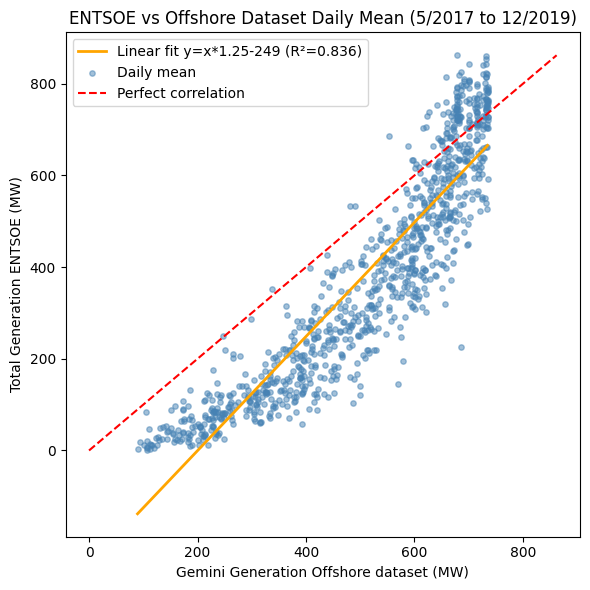

In [113]:
# Weekly resampled data
y = gemini_period_df["Generation_ENTSOE"].resample("D").mean().dropna()
x = gemini_period_df["Generation_offshore_plus_baseline"].resample("D").mean().dropna()

# Linear fit
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

print(f"Slope:     {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R²:        {r_value**2:.4f}")
print(f"R:         {r_value:.4f}")
print(f"P-value:   {p_value:.6f}")
print(f"Std error: {std_err:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

# Linear fit line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color="orange", linewidth=2, label=f"Linear fit y=x*{slope:.2f}{intercept:.0f} (R²={r_value**2:.3f})")

ax.scatter(x, y, alpha=0.5, s=15, color="steelblue", label="Daily mean")

max_val = max(x.max(), y.max())
ax.plot([0, max_val], [0, max_val], color="red", linestyle="--", linewidth=1.5, label="Perfect correlation")

ax.set_xlabel("Gemini Generation Offshore dataset (MW)")
ax.set_ylabel("Total Generation ENTSOE (MW)")
ax.legend()
plt.title("ENTSOE vs Offshore Dataset Daily Mean (5/2017 to 12/2019)")
plt.tight_layout()
plt.show()

Slope:     1.2958
Intercept: -151.6647
R²:        0.8295
R:         0.9108
P-value:   0.000000
Std error: 0.0189


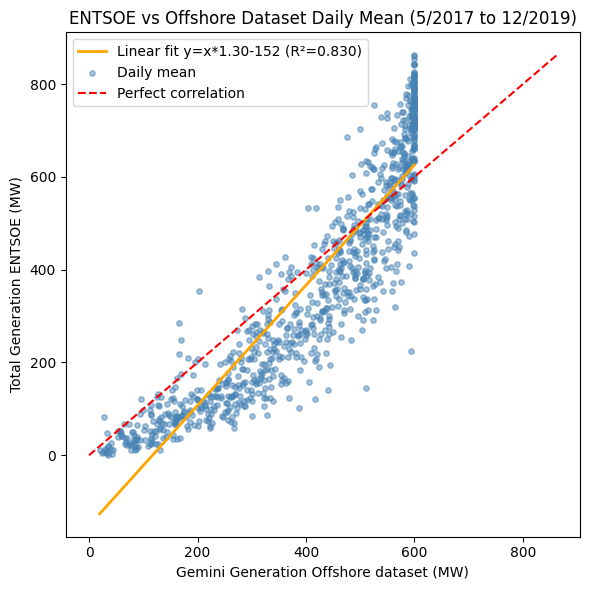

In [114]:
# Weekly resampled data
y = gemini_period_df["Generation_ENTSOE"].resample("D").mean().dropna()
x = gemini_period_df["Generation_offshore"].resample("D").mean().dropna()

# Linear fit
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

print(f"Slope:     {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R²:        {r_value**2:.4f}")
print(f"R:         {r_value:.4f}")
print(f"P-value:   {p_value:.6f}")
print(f"Std error: {std_err:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

# Linear fit line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color="orange", linewidth=2, label=f"Linear fit y=x*{slope:.2f}{intercept:.0f} (R²={r_value**2:.3f})")

ax.scatter(x, y, alpha=0.5, s=15, color="steelblue", label="Daily mean")

max_val = max(x.max(), y.max())
ax.plot([0, max_val], [0, max_val], color="red", linestyle="--", linewidth=1.5, label="Perfect correlation")

ax.set_xlabel("Gemini Generation Offshore dataset (MW)")
ax.set_ylabel("Total Generation ENTSOE (MW)")
ax.legend()
plt.title("ENTSOE vs Offshore Dataset Daily Mean (5/2017 to 12/2019)")
plt.tight_layout()
plt.show()

Slope:     1.2958
Intercept: -151.6647
R²:        0.8295
R:         0.9108
P-value:   0.000000
Std error: 0.0189


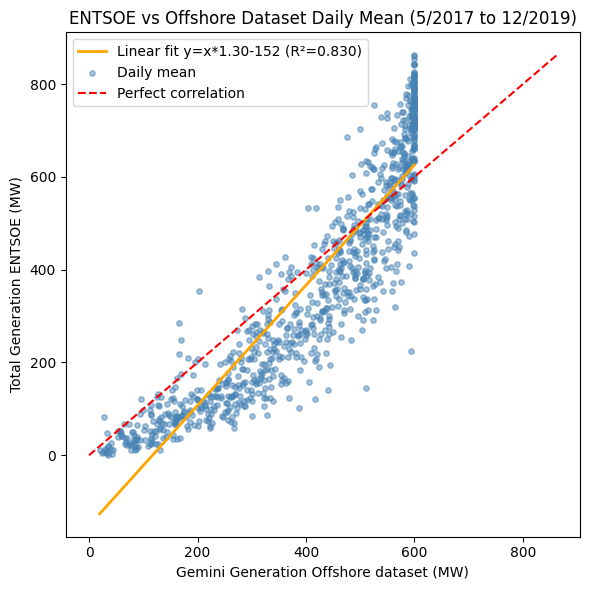

In [115]:
# Weekly resampled data
y = gemini_period_df["Generation_ENTSOE"].resample("D").mean().dropna()
x = gemini_period_df["Generation_offshore"].resample("D").mean().dropna()

# Linear fit
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

print(f"Slope:     {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R²:        {r_value**2:.4f}")
print(f"R:         {r_value:.4f}")
print(f"P-value:   {p_value:.6f}")
print(f"Std error: {std_err:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

# Linear fit line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color="orange", linewidth=2, label=f"Linear fit y=x*{slope:.2f}{intercept:.0f} (R²={r_value**2:.3f})")

ax.scatter(x, y, alpha=0.5, s=15, color="steelblue", label="Daily mean")

max_val = max(x.max(), y.max())
ax.plot([0, max_val], [0, max_val], color="red", linestyle="--", linewidth=1.5, label="Perfect correlation")

ax.set_xlabel("Gemini Generation Offshore dataset (MW)")
ax.set_ylabel("Total Generation ENTSOE (MW)")
ax.legend()
plt.title("ENTSOE vs Offshore Dataset Daily Mean (5/2017 to 12/2019)")
plt.tight_layout()
plt.show()

In [116]:
# Calculate monthly median of baseline period
# baseline = entso_timeseries_df[
#     (entso_timeseries_df.index >= baseline_start) &
#     (entso_timeseries_df.index < gemini_start)
# ]
# monthly_baseline_median = baseline.groupby(baseline.index.month)["Generation_MW"].median()
#
# # Scale each row by subtracting the monthly baseline first, then clip negatives
# gemini_period_df["Generation_excl_baseline_monthly"] = gemini_period_df.apply(
#     lambda row: (row["Generation_MW"] - monthly_baseline_median[row.name.month]) *
#                 (600 / (600 + pre_gemini_max - monthly_baseline_median[row.name.month])),
#     axis=1
# )

In [117]:
# fig, ax = plt.subplots(figsize=(14, 5))
#
# ax.axhline(y=600, color="red", linewidth=1.5, linestyle="--", label="Gemini Max Capacity (600 MW)")
#
# ax.plot(gemini_period_df["Generation_excl_baseline_monthly"].resample("W").mean(),
#         color="steelblue", alpha=0.7, label="Scaled Total Generation ENTSOE monthly corrected (MW)")
#
# ax.plot(gemini_period_df["Generation_offshore"].resample("W").mean(),
#         color="green", alpha=0.7, label="Gemini Generation Offshore dataset (MW)")
#
# ax.set_ylabel("MW")
# ax.legend()
# plt.title("Offshore Wind Generation vs Installed Capacity (monthly baseline corrected)")
# plt.tight_layout()
# plt.show()

In [118]:
# mae = mean_absolute_error(gemini_period_df["Generation_excl_baseline_monthly"], gemini_period_df["Generation_offshore"])
# rmse = np.sqrt(((gemini_period_df["Generation_offshore"] - gemini_period_df["Generation_excl_baseline_monthly"])**2).mean())
# correlation = gemini_period_df["Generation_offshore"].corr(gemini_period_df["Generation_excl_baseline_monthly"])
# print(f"mae: {mae}, rmse: {rmse}, correlation: {correlation}")

In [119]:
gemini_period_df["Generation_MW_linear_scaled"] = (gemini_period_df["Generation_offshore"] * 1.3) - 152

# Recompute metrics
mae_scaled = mean_absolute_error(gemini_period_df["Generation_MW_linear_scaled"], gemini_period_df["Generation_ENTSOE"])
correlation_scaled = gemini_period_df["Generation_MW_linear_scaled"].corr(gemini_period_df["Generation_ENTSOE"])
print(f"MAE after scaling: {mae_scaled}, correlation: {correlation_scaled}")

MAE after scaling: 119.07042514411565, correlation: 0.8562697376194961


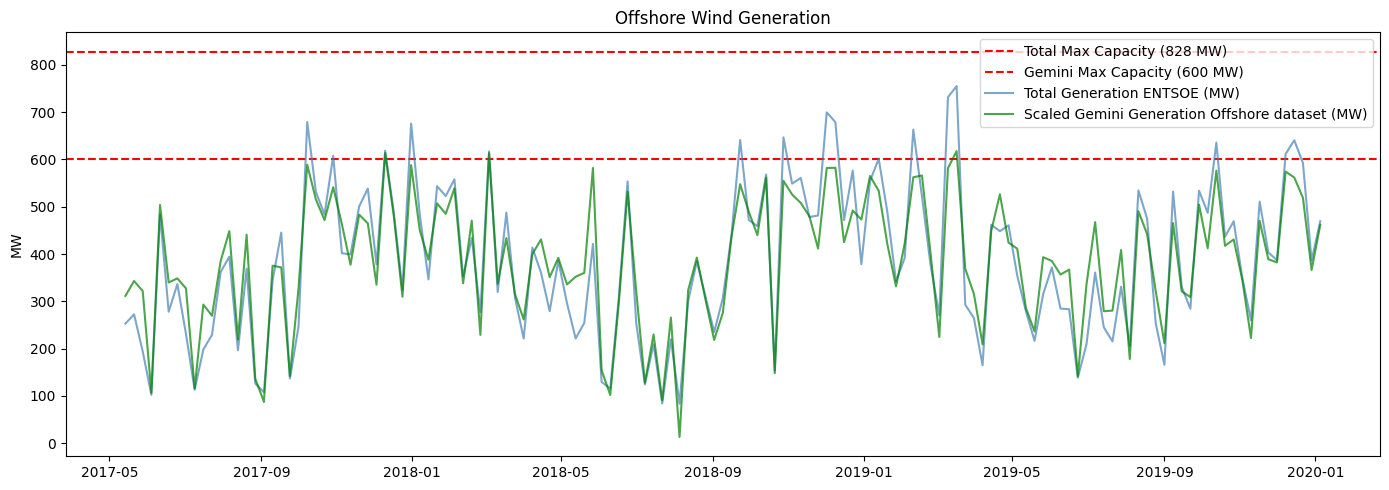

In [120]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.axhline(y=828, color="red", linewidth=1.5, linestyle="--", label="Total Max Capacity (828 MW)")
ax.axhline(y=600, color="red", linewidth=1.5, linestyle="--", label="Gemini Max Capacity (600 MW)")

ax.plot(gemini_period_df["Generation_ENTSOE"].resample("W").mean(),
        color="steelblue", alpha=0.7, label="Total Generation ENTSOE (MW)")

ax.plot(gemini_period_df["Generation_MW_linear_scaled"].resample("W").mean(),
        color="green", alpha=0.7, label="Scaled Gemini Generation Offshore dataset (MW)")

ax.set_ylabel("MW")
ax.legend()
plt.title("Offshore Wind Generation")
plt.tight_layout()
plt.show()

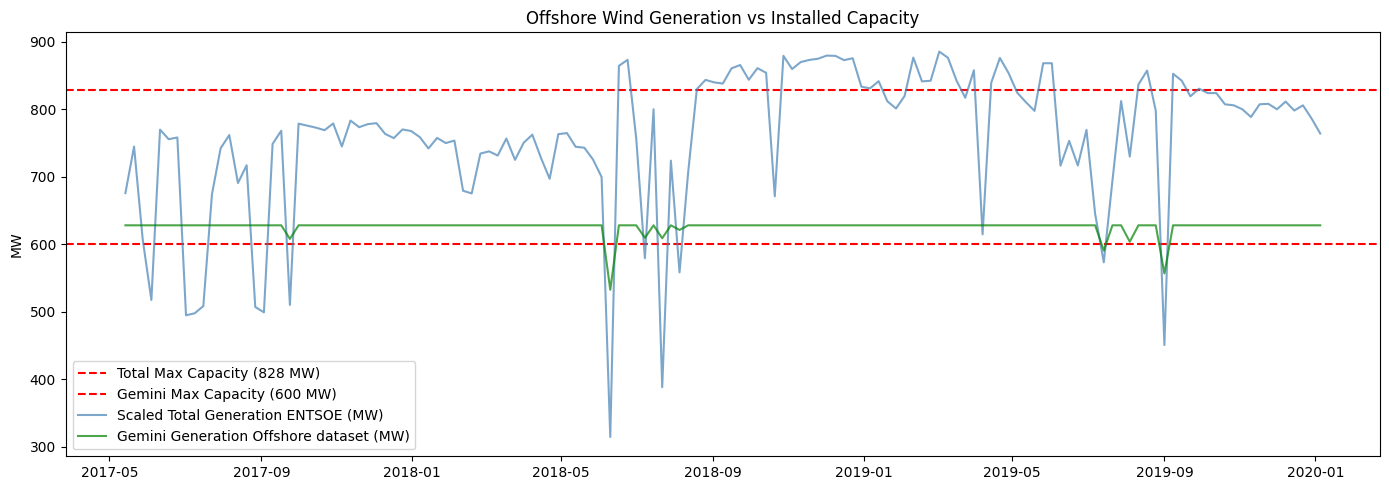

In [121]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.axhline(y=828, color="red", linewidth=1.5, linestyle="--", label="Total Max Capacity (828 MW)")
ax.axhline(y=600, color="red", linewidth=1.5, linestyle="--", label="Gemini Max Capacity (600 MW)")

ax.plot(gemini_period_df["Generation_ENTSOE"].resample("W").max(),
        color="steelblue", alpha=0.7, label="Scaled Total Generation ENTSOE (MW)")

ax.plot(gemini_period_df["Generation_MW_linear_scaled"].resample("W").max(),
        color="green", alpha=0.7, label="Gemini Generation Offshore dataset (MW)")

ax.set_ylabel("MW")
ax.legend()
plt.title("Offshore Wind Generation vs Installed Capacity")
plt.tight_layout()
plt.show()

In [122]:
for freq in ["h", "D", "W", "ME"]:
    entso_resampled = gemini_period_df["Generation_MW_linear_scaled"].resample(freq).mean()
    offshore_resampled = gemini_period_df["Generation_ENTSOE"].resample(freq).mean()

    # Drop NaNs for the comparison
    mask = entso_resampled.notna() & offshore_resampled.notna()

    r = entso_resampled[mask].corr(offshore_resampled[mask])
    mae = mean_absolute_error(entso_resampled[mask], offshore_resampled[mask])
    rmse = np.sqrt(((entso_resampled[mask] - offshore_resampled[mask])**2).mean())

    print(f"{freq}: correlation: {r:.3f}, MAE: {mae:.1f}, RMSE: {rmse:.1f}")

h: correlation: 0.856, MAE: 119.1, RMSE: 145.1
D: correlation: 0.911, MAE: 81.0, RMSE: 99.2
W: correlation: 0.938, MAE: 45.2, RMSE: 57.4
ME: correlation: 0.960, MAE: 32.0, RMSE: 39.8


In [123]:
# MAE consitent therefore errro probaly systematic (offset)

In [124]:
for freq in ["h", "D", "W", "ME"]:
    entso_resampled = gemini_period_df["Generation_offshore"].resample(freq).mean()
    offshore_resampled = gemini_period_df["Generation_ENTSOE"].resample(freq).mean()

    # Drop NaNs for the comparison
    mask = entso_resampled.notna() & offshore_resampled.notna()

    r = entso_resampled[mask].corr(offshore_resampled[mask])
    mae = mean_absolute_error(entso_resampled[mask], offshore_resampled[mask])
    rmse = np.sqrt(((entso_resampled[mask] - offshore_resampled[mask])**2).mean())

    print(f"{freq}: correlation: {r:.3f}, MAE: {mae:.1f}, RMSE: {rmse:.1f}")

h: correlation: 0.856, MAE: 124.2, RMSE: 150.1
D: correlation: 0.911, MAE: 96.5, RMSE: 114.9
W: correlation: 0.938, MAE: 65.7, RMSE: 78.1
ME: correlation: 0.960, MAE: 49.4, RMSE: 61.4


In [125]:
gemini_period_df["Generation_MW_plus_correction"] = gemini_period_df["Generation_offshore"] + (gemini_period_df["Generation_offshore"] / gemini_period_df["Generation_offshore"].max()) * 228

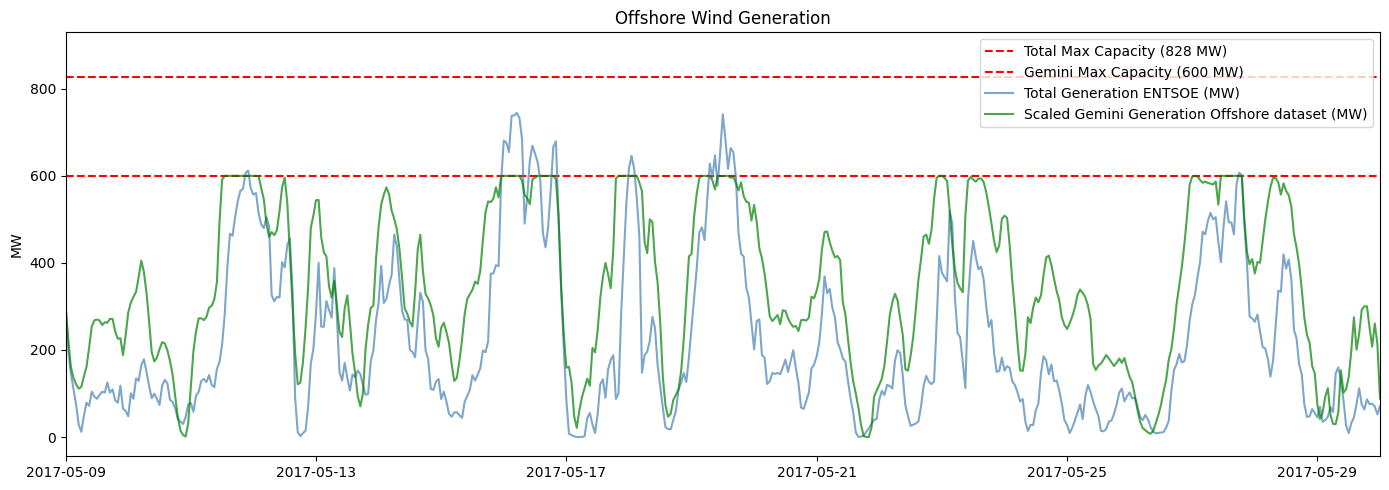

In [126]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.axhline(y=828, color="red", linewidth=1.5, linestyle="--", label="Total Max Capacity (828 MW)")
ax.axhline(y=600, color="red", linewidth=1.5, linestyle="--", label="Gemini Max Capacity (600 MW)")

ax.plot(gemini_period_df["Generation_ENTSOE"].resample("h").mean(),
        color="steelblue", alpha=0.7, label="Total Generation ENTSOE (MW)")

ax.plot(gemini_period_df["Generation_offshore"].resample("h").mean(),
        color="green", alpha=0.7, label="Scaled Gemini Generation Offshore dataset (MW)")

ax.set_ylabel("MW")
ax.legend()
ax.set_xlim(pd.Timestamp("2017-05-09"), pd.Timestamp("2017-05-30"))
plt.title("Offshore Wind Generation")
plt.tight_layout()
plt.show()

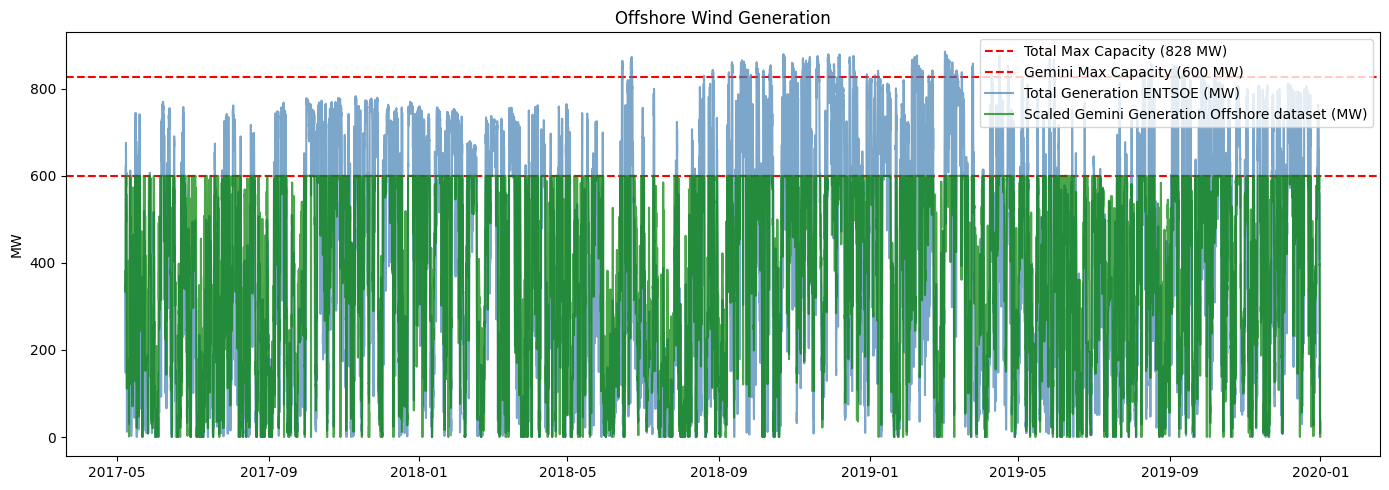

In [138]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.axhline(y=828, color="red", linewidth=1.5, linestyle="--", label="Total Max Capacity (828 MW)")
ax.axhline(y=600, color="red", linewidth=1.5, linestyle="--", label="Gemini Max Capacity (600 MW)")

ax.plot(gemini_period_df["Generation_ENTSOE"].resample("h").mean(),
        color="steelblue", alpha=0.7, label="Total Generation ENTSOE (MW)")

ax.plot(gemini_period_df["Generation_offshore"].resample("h").mean(),
        color="green", alpha=0.7, label="Scaled Gemini Generation Offshore dataset (MW)")

ax.set_ylabel("MW")
ax.legend()
#ax.set_xlim(pd.Timestamp("2017-05-09"), pd.Timestamp("2017-05-30"))
plt.title("Offshore Wind Generation")
plt.tight_layout()
plt.show()

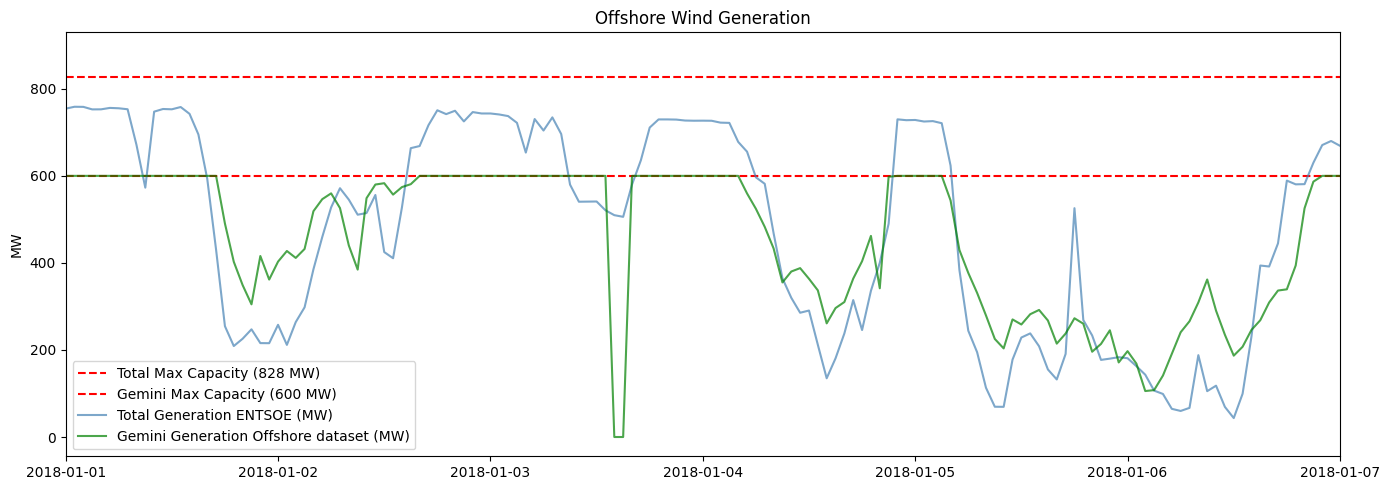

In [147]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.axhline(y=828, color="red", linewidth=1.5, linestyle="--", label="Total Max Capacity (828 MW)")
ax.axhline(y=600, color="red", linewidth=1.5, linestyle="--", label="Gemini Max Capacity (600 MW)")

ax.plot(gemini_period_df["Generation_ENTSOE"].resample("h").mean(),
        color="steelblue", alpha=0.7, label="Total Generation ENTSOE (MW)")

ax.plot(gemini_period_df["Generation_offshore"].resample("h").mean(),
        color="green", alpha=0.7, label="Gemini Generation Offshore dataset (MW)")

ax.set_ylabel("MW")
ax.legend()
ax.set_xlim(pd.Timestamp("2018-01-01"), pd.Timestamp("2018-01-07"))
plt.title("Offshore Wind Generation")
plt.tight_layout()
plt.show()